# Self-Supervised Learning | SimCLR

[Contrastive Representation Learning](https://lilianweng.github.io/posts/2021-05-31-contrastive/) is motivated by the question: "how are images different from each other?"

## SimCLR

A Simple Framework for Contrastive Learning of Visual Representations

* [ICML 2020 presentation](https://icml.cc/media/icml-2020/Slides/6762.pdf)
* [github (official)](https://github.com/google-research/simclr)

<img src="images/SimCLR_summary.png" alt="SimCLR_summary" width="600"/>

### Imports

In [1]:
import os
import torch
import torchvision
import matplotlib.pyplot as plt

from einops import rearrange
from tqdm.notebook import tqdm

from utils import make_reproducible

### Global Variables

In [2]:
DATA_PATH = os.path.join(".", "data")
CHECKPOINT_DIR = os.path.join(".", "checkpoints")

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

#### Reproducibility

In [3]:
make_reproducible(seed=0)

### Data Augmentation for Contrastive Learning

![SimCLR_data_augmentation](images/SimCLR_data_augmentation.png)

In [4]:
class ContrastiveTransform(object):
    def __init__(self, transform, num_transformed_images=2):
        self.transform = transform
        self.num_transformed_images = num_transformed_images

    def __call__(self, image):
        return [self.transform(image) for _ in range(self.num_transformed_images)]

What augmentations stand out?

* crop-and-resize
* color jittering

More precisely, their combination is important!

After crop and resize:

* In case (a) the model is required to be scale invariant to make crops A and B similar in latent space.
* In case (b) the model can not reason that two patches belong to the same image without actually recognizing the objects if we distort the colors randomly and independently of each other.

<img src="images/cropping.svg" alt="cropping" width="600"/>

In [5]:
from torchvision.transforms import (RandomResizedCrop, RandomHorizontalFlip, RandomGrayscale, RandomApply,
                                    ColorJitter, GaussianBlur, ToTensor, Normalize, Compose)

possible_augmentation_transform = Compose([RandomResizedCrop(size=96),
                                           RandomApply([ColorJitter(brightness=0.5,
                                                                    contrast=0.5,
                                                                    saturation=0.5,
                                                                    hue=0.1)],
                                                       p=0.8),
                                           RandomGrayscale(p=0.2),
                                           RandomHorizontalFlip(),
                                           GaussianBlur(kernel_size=9),
                                           ToTensor(),
                                           Normalize((0.5,), (0.5,))])

contrastive_transform = ContrastiveTransform(transform=possible_augmentation_transform)

### Dataset

We will use [STL-10](https://cs.stanford.edu/~acoates/stl10/) dataset.\
This is an image recognition dataset for developing unsupervised feature learning, inspired by the CIFAR-10.

In [6]:
unlabeled_data = torchvision.datasets.STL10(root=DATA_PATH, split='unlabeled', download=True, transform=contrastive_transform)
val_data = torchvision.datasets.STL10(root=DATA_PATH, split='train', download=True, transform=contrastive_transform)

100%|██████████| 2.64G/2.64G [07:23<00:00, 5.95MB/s] 


In [ ]:
NUM_IMAGES = 6

images = [torchvision.utils.make_grid(unlabeled_data[index][0], nrow=1, padding=10, normalize=True, pad_value=1)
          for index in range(NUM_IMAGES)]
images_grid = torchvision.utils.make_grid(images, nrow=NUM_IMAGES, normalize=True, pad_value=1)
images_grid = rearrange(images_grid, "c h w -> h w c")

plt.figure(figsize=(10, 5))
plt.title("Augmented image examples of the STL10 dataset")
plt.imshow(images_grid)
plt.axis('off')
plt.show()

### Model

We will use a deep CNN $f(\cdot)$ as the base encoder network (_e.g._, [ResNet18](https://pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html)) and a two-layer MLP with ReLU activation as the projection head $g(\cdot)$.

<img src="images/SimCLR_model.svg" alt="SimCLR_model" width="400"/>

In [6]:
class SimCLR(torch.nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.hidden_dim = hidden_dim
        
        self.encoder = torchvision.models.resnet18(num_classes=4*hidden_dim)
        self.encoder.fc = torch.nn.Sequential(self.encoder.fc,
                                              torch.nn.ReLU(inplace=True),
                                              torch.nn.Linear(4*hidden_dim, hidden_dim))

    def forward(self, tensor):
        return self.encoder(tensor)

### Info NCE Loss

The loss function based on Noise Contrastive Estimation (NCE) loss, originally proposed in [Representation Learning with Contrastive Predictive Coding](https://arxiv.org/pdf/1807.03748).

In [7]:
class InfoNCELoss(torch.nn.Module):
    def __init__(self, temperature):
        super().__init__()

        self.temperature = temperature

    def forward(self, features_1, features_2):
        cosine_similarity = torch.nn.functional.cosine_similarity(rearrange(features_1, 'batch hidden -> batch 1 hidden'),
                                                                  rearrange(features_2, 'batch hidden -> 1 batch hidden'),
                                                                  dim=-1)
        cosine_similarity = cosine_similarity / self.temperature

        self_mask = torch.eye(cosine_similarity.shape[0], dtype=torch.bool, device=cosine_similarity.device)
        nll = -cosine_similarity[self_mask] + torch.logsumexp(cosine_similarity.fill_diagonal_(-float('inf')), dim=-1)
        
        return nll.mean()

    def compute_ideal_loss(self, batch_size):
        return (-2.0/self.temperature + torch.log(torch.tensor(batch_size - 1))).item()

### Training

In [ ]:
class Trainer(object):
    def __init__(self, model, objective_function, optimizer, scheduler, device, checkpoint_dir):
        self.model = model
        self.objective_function = objective_function
        self.optimizer = optimizer
        self.scheduler = scheduler
        
        self.device = device
        
        self.checkpoint_dir = checkpoint_dir

    def train(self, train_dataloader, val_dataloader, num_epochs):
        for epoch in range(1, num_epochs + 1):
            self.run_epoch(dataloader=train_dataloader, epoch=epoch, phase='train')
            self.run_epoch(dataloader=val_dataloader, epoch=epoch, phase='val')
            
            if self.scheduler is not None:
                self.scheduler.step()

            self.save_checkpoint(epoch=epoch)

    def run_epoch(self, dataloader, epoch, phase):
        is_train = (phase == 'train')

        self.model.train() if is_train else self.model.eval()
        
        with torch.set_grad_enabled(is_train):
            for item in tqdm(iterable=dataloader, desc=f"Epoch {epoch:02} | {phase}", leave=False, unit='batch'):
                images, _ = item

                features_1 = self.model(images[0].to(self.device))
                features_2 = self.model(images[1].to(self.device))
                
                loss = self.objective_function(features_1, features_2)

                if is_train:
                    self._optimize(loss)

    def _optimize(self, objective):
        self.optimizer.zero_grad()
        objective.backward()
        self.optimizer.step()

    def save_checkpoint(self, epoch):
        checkpoint = {'epoch': epoch,
                      'model_state_dict': self.model.state_dict(),
                      'optimizer_state_dict': self.optimizer.state_dict()}

        os.makedirs(self.checkpoint_dir, exist_ok=True)
        torch.save(checkpoint, os.path.join(self.checkpoint_dir, "model.pth.tar"))

In [ ]:
BATCH_SIZE = 256
NUM_WORKERS = 8
MAX_EPOCHS = 500
LOSS_TEMPERATURE = 0.07

train_dataloader = torch.utils.data.DataLoader(unlabeled_data,
                                               batch_size=BATCH_SIZE,
                                               shuffle=True,
                                               drop_last=True,
                                               pin_memory=True,
                                               num_workers=NUM_WORKERS)
val_dataloader = torch.utils.data.DataLoader(val_data,
                                             batch_size=BATCH_SIZE,
                                             shuffle=False,
                                             drop_last=False,
                                             pin_memory=True,
                                             num_workers=NUM_WORKERS)

model = SimCLR(hidden_dim=128)
model.to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=5.0e-4, weight_decay=1.0e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS, eta_min=1.0e-5)

objective_function = InfoNCELoss(temperature=LOSS_TEMPERATURE)

In [ ]:
trainer = Trainer(model=model,
                  objective_function=objective_function,
                  optimizer=optimizer,
                  scheduler=scheduler,
                  device=DEVICE,
                  checkpoint_dir=CHECKPOINT_DIR)

In [ ]:
NUM_EPOCHS = 10

trainer.train(train_dataloader=train_dataloader,
              val_dataloader=val_dataloader,
              num_epochs=NUM_EPOCHS)

### Let's Find the Closest Image

In [8]:
def load_checkpoint(checkpoint_dir, device):
    checkpoint_path = os.path.join(checkpoint_dir, "pretrained_model.pth.tar")
    checkpoint = torch.load(checkpoint_path, map_location=device)

    epoch = checkpoint.get('epoch')
    model_state_dict = checkpoint.get('model_state_dict')
    optimizer_state_dict = checkpoint.get('optimizer_state_dict')

    return epoch, model_state_dict, optimizer_state_dict

In [9]:
epoch, model_state_dict, optimizer_state_dict = load_checkpoint(checkpoint_dir=CHECKPOINT_DIR, device=DEVICE)
model = SimCLR(hidden_dim=128)
model.to(DEVICE)
model.load_state_dict(model_state_dict)
model.eval();

In [10]:
def find_closest_image(model, image_index, dataset):
    model.eval()
    
    with torch.no_grad():
        image_features = model(dataset[image_index][0].unsqueeze(dim=0).to(DEVICE))

        best_similarity = -1.0
        closest_image = None
        for i in tqdm(iterable=range(len(dataset)), desc="Search for the closest image", leave=False, unit='image'):
            if i == image_index:
                continue
            
            features = model(dataset[i][0].unsqueeze(dim=0).to(DEVICE))
            cosine_similarity = torch.nn.functional.cosine_similarity(rearrange(image_features, 'batch hidden -> batch 1 hidden'),
                                                                      rearrange(features, 'batch hidden -> 1 batch hidden'),
                                                                      dim=-1).mean().item()
            
            if cosine_similarity > best_similarity:
                best_similarity = cosine_similarity
                closest_image = dataset[i][0]

    return closest_image, best_similarity

In [12]:
test_transform = Compose([ToTensor(),
                          Normalize((0.5,), (0.5,))])
test_data = torchvision.datasets.STL10(root=DATA_PATH, split='train', download=True, transform=test_transform)

Files already downloaded and verified


In [14]:
image_indices = [300, 20, 800, 900, 1000, 3000]
images = [test_data[index][0] for index in image_indices]

closest_images = []
for image_index in image_indices:
    closest_image, _ = find_closest_image(model=model, image_index=image_index, dataset=test_data)
    closest_images.append(closest_image)

Search for the closest image:   0%|          | 0/5000 [00:00<?, ?image/s]

Search for the closest image:   0%|          | 0/5000 [00:00<?, ?image/s]

Search for the closest image:   0%|          | 0/5000 [00:00<?, ?image/s]

Search for the closest image:   0%|          | 0/5000 [00:00<?, ?image/s]

Search for the closest image:   0%|          | 0/5000 [00:00<?, ?image/s]

Search for the closest image:   0%|          | 0/5000 [00:00<?, ?image/s]

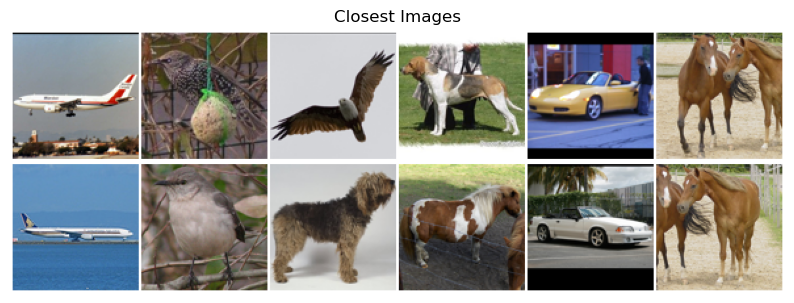

In [15]:
images_grid = torch.cat([torchvision.utils.make_grid(images, nrow=len(images), normalize=True, pad_value=1),
                         torchvision.utils.make_grid(closest_images, nrow=len(closest_images), normalize=True, pad_value=1)],
                        dim=1)

images_grid = rearrange(images_grid, "c h w -> h w c")

plt.figure(figsize=(10, 5))
plt.title("Closest Images")
plt.imshow(images_grid)
plt.axis('off')
plt.show()